Below is an example of training a simple neural network to fit the function $f(\mathbf{x})$,

$$
f(\mathbf{x}) = \sin(x) + 2\cos(x)
$$

In [922]:
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

device = torch.device("cpu")
# add generator for consistency between runs
gen = torch.Generator(device=device).manual_seed(1)

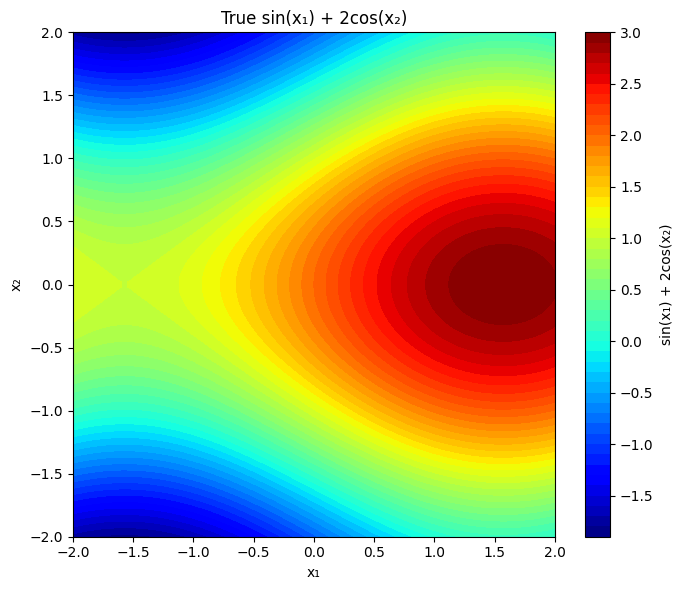

In [923]:
# True function
points_per_dim = 100

linx1 = torch.linspace(-2, 2, points_per_dim)
linx2 = torch.linspace(-2, 2, points_per_dim)
x1, x2 = torch.meshgrid(linx1, linx2, indexing='ij')

z = torch.sin(x1) + 2 * torch.cos(x2)

plt.figure(figsize=(7, 6))
plt.contourf(x1.numpy(), x2.numpy(), z.numpy(), levels=50, cmap='jet')
plt.colorbar(label='sin(x₁) + 2cos(x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('True sin(x₁) + 2cos(x₂)')
plt.tight_layout()
plt.show()


In [924]:
# Layer 0 (input layer)
# N x D
# we are using row vectors
n_samples = 50
x_train = torch.rand(n_samples, 2, generator=gen) * 4 - 2

In [925]:
# layer 1
layer1_weights = torch.randn((3, 2), requires_grad=True, generator=gen)
layer1_bias = torch.randn(3, requires_grad=True, generator=gen)
layer1_z = x_train @ layer1_weights.T + layer1_bias
layer1_a = F.tanh(layer1_z)
layer1_a.shape

torch.Size([50, 3])

In [926]:
# layer 2
layer2_weights = torch.randn((4, 3), requires_grad=True, generator=gen)
layer2_bias = torch.randn(4, requires_grad=True, generator=gen)
layer2_z = layer1_a @ layer2_weights.T + layer2_bias
layer2_a = F.tanh(layer2_z)
layer2_a.shape

torch.Size([50, 4])

In [927]:
# layer 3 (Output Layer)
layer3_weights = torch.randn((1, 4), requires_grad=True, generator=gen)
layer3_bias = torch.randn(1, requires_grad=True, generator=gen)
predicted = layer2_a @ layer3_weights.T + layer3_bias
predicted.shape

torch.Size([50, 1])

In [928]:
# Loss function
y_train = torch.sin(x_train[:, 0]) + 2 * torch.cos(x_train[:, 1])  # shape (n_samples,)
y_train = y_train.unsqueeze(1) # shape (n_samples, 1)

loss = torch.sum((predicted - y_train)**2) / n_samples

loss

tensor(4.0368, grad_fn=<DivBackward0>)

In [929]:
# gradient check against torch

delta_output_layer = (2 / n_samples) * (predicted - y_train)
grad_W3 = delta_output_layer.T @ layer2_a
grad_b3 = torch.sum(delta_output_layer, dim=0)
delta_a2 = (delta_output_layer @ layer3_weights) * (1-torch.tanh(layer2_z)**2)
grad_W2 = delta_a2.T @ layer1_a
grad_b2 = torch.sum(delta_a2, dim=0)
delta_a1 = (delta_a2 @ layer2_weights) * (1-torch.tanh(layer1_z)**2)
grad_W1 = delta_a1.T @ x_train
grad_b1 = torch.sum(delta_a1, dim=0)

In [930]:
print("Manual backpropagation")
print("Layer 3")
print(grad_W3)
print(grad_b3)

print("Layer 2")
print(grad_W2)
print(grad_b2)

print("Layer 1")
print(grad_W1)
print(grad_b1)

Manual backpropagation
Layer 3
tensor([[-2.1670,  0.7036, -3.1546,  2.9928]], grad_fn=<MmBackward0>)
tensor([-3.6683], grad_fn=<SumBackward1>)
Layer 2
tensor([[-1.0560e-01, -1.1282e-01, -1.9859e-02],
        [ 3.2665e-01, -1.0052e+00,  5.4651e-01],
        [-1.7088e-04,  4.5990e-02, -3.5454e-02],
        [ 3.7575e-02, -9.2994e-01,  3.4449e-01]], grad_fn=<MmBackward0>)
tensor([-0.3193,  1.9043,  0.1187,  1.1953], grad_fn=<SumBackward1>)
Layer 1
tensor([[-0.4742,  0.2173],
        [-0.4962, -0.0091],
        [-0.0633,  0.1798]], grad_fn=<MmBackward0>)
tensor([0.1661, 0.6730, 0.3572], grad_fn=<SumBackward1>)


In [931]:
# torch gradients
loss.backward()

In [932]:
print("Torch backpropagation")
print("Layer 3")
print(layer3_weights.grad)
print(layer3_bias.grad)

print("Layer 2")
print(layer2_weights.grad)
print(layer2_bias.grad)

print("Layer 1")
print(layer1_weights.grad)
print(layer1_bias.grad)

Torch backpropagation
Layer 3
tensor([[-2.1670,  0.7036, -3.1546,  2.9928]])
tensor([-3.6683])
Layer 2
tensor([[-1.0560e-01, -1.1282e-01, -1.9859e-02],
        [ 3.2665e-01, -1.0052e+00,  5.4651e-01],
        [-1.7088e-04,  4.5990e-02, -3.5454e-02],
        [ 3.7575e-02, -9.2994e-01,  3.4449e-01]])
tensor([-0.3193,  1.9043,  0.1187,  1.1953])
Layer 1
tensor([[-0.4742,  0.2173],
        [-0.4962, -0.0091],
        [-0.0633,  0.1798]])
tensor([0.1661, 0.6730, 0.3572])


In [933]:
# training loop

LR = 0.1

with torch.no_grad():
    for i in range(1, 1001):

        # forward pass (must recompute each iteration with updated weights)
        layer1_z = x_train @ layer1_weights.T + layer1_bias
        layer1_a = F.tanh(layer1_z)
        layer2_z = layer1_a @ layer2_weights.T + layer2_bias
        layer2_a = F.tanh(layer2_z)
        predicted = layer2_a @ layer3_weights.T + layer3_bias

        # current loss
        loss = torch.sum((predicted - y_train)**2) / n_samples

        if i % 100 == 0:
            print(f"Iteration: {i}, loss: {loss}")

        # backpropagation to find gradients
        delta_output_layer = (2 / n_samples) * (predicted - y_train)
        grad_W3 = delta_output_layer.T @ layer2_a
        grad_b3 = torch.sum(delta_output_layer, dim=0)
        delta_a2 = (delta_output_layer @ layer3_weights) * (1-torch.tanh(layer2_z)**2)
        grad_W2 = delta_a2.T @ layer1_a
        grad_b2 = torch.sum(delta_a2, dim=0)
        delta_a1 = (delta_a2 @ layer2_weights) * (1-torch.tanh(layer1_z)**2)
        grad_W1 = delta_a1.T @ x_train
        grad_b1 = torch.sum(delta_a1, dim=0)

        # go against gradient of parameters because we want to minimize loss
        layer3_weights -= LR * grad_W3
        layer3_bias -= LR * grad_b3

        layer2_weights -= LR * grad_W2
        layer2_bias -= LR * grad_b2

        layer1_weights -= LR * grad_W1
        layer1_bias -= LR * grad_b1

Iteration: 100, loss: 0.16973374783992767
Iteration: 200, loss: 0.056029144674539566
Iteration: 300, loss: 0.03114660270512104
Iteration: 400, loss: 0.021778529509902
Iteration: 500, loss: 0.015718160197138786
Iteration: 600, loss: 0.011647904291749
Iteration: 700, loss: 0.008852070197463036
Iteration: 800, loss: 0.006901008076965809
Iteration: 900, loss: 0.005522711668163538
Iteration: 1000, loss: 0.004533101804554462


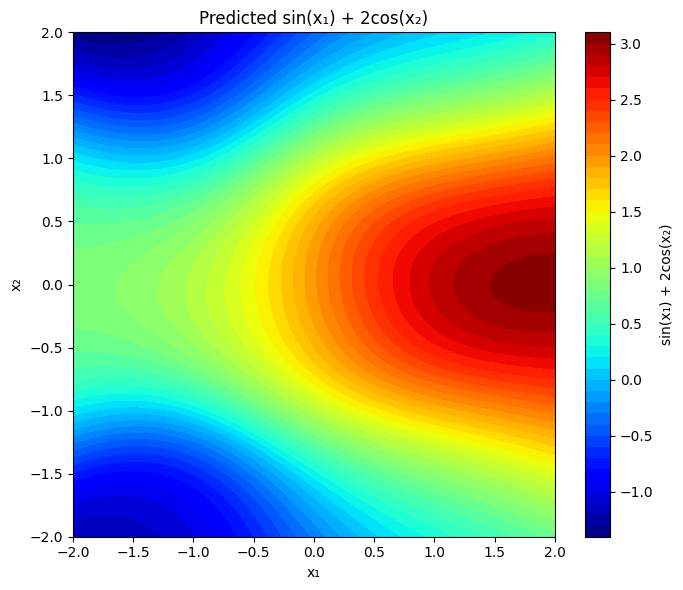

In [934]:
linx1_test = torch.linspace(-2, 2, points_per_dim)
linx2_test = torch.linspace(-2, 2, points_per_dim)
x1, x2 = torch.meshgrid(linx1_test, linx2_test, indexing='ij')

grid_input = torch.stack([x1.flatten(), x2.flatten()], dim=1)

with torch.no_grad():
    layer1_z = grid_input @ layer1_weights.T + layer1_bias
    layer1_a = F.tanh(layer1_z)

    layer2_z = layer1_a @ layer2_weights.T + layer2_bias
    layer2_a = F.tanh(layer2_z)

    predicted = layer2_a @ layer3_weights.T + layer3_bias

    predicted = predicted.reshape(points_per_dim, points_per_dim)

plt.figure(figsize=(7, 6))
plt.contourf(x1.numpy(), x2.numpy(), predicted.numpy(), levels=50, cmap='jet')
plt.colorbar(label='sin(x₁) + 2cos(x₂)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Predicted sin(x₁) + 2cos(x₂)')
plt.tight_layout()
plt.show()
